#### Import packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, recall_score, accuracy_score,
    classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay,
)
from sklearn import set_config

warnings.filterwarnings('ignore')
set_config(transform_output='pandas')

In [ ]:
pip install dagshub mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.0/274.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.8/222.8 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
import dagshub
dagshub.init(repo_owner='Ankitkumar1141', repo_name='Churn-modelling', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=c718f31c-be5e-42f3-9210-ec2837ddff2f&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=5e3c15bf5995320499520bc0c7a0ed3d9ac1915e09fef50a925939cfb249bd3a




Accessing as Ankitkumar1141

Initialized MLflow to track repo "Ankitkumar1141/Churn-modelling"

Repository Ankitkumar1141/Churn-modelling initialized!

# Load the preprocessed Data

In [ ]:
df = pd.read_csv("preprocessed.csv")
print('Shape:', df.shape)
df.head()

Shape: (10000, 37)


,customer_id,name,gender,age,salary,location_id,churned,account_id,tenure,balance,...,is_single_product,inactive_senior,engagement_score,high_risk_inactive,is_female,geo_france,geo_germany,geo_spain,geo_uk,geo_usa
0,15634602,Hargrave,female,42,101348.88,2,1,A15634602SID,2,NaN,...,1,0,0.750000,0,1,1,0,0,0,0
1,15647311,Hill,female,41,112542.58,6,0,A15647311SID,1,83807.86,...,1,0,0.416667,0,1,0,0,0,0,1
2,15619304,Onio,female,42,113931.57,4,1,A15619304SID,8,159660.80,...,0,0,0.583333,0,1,0,0,0,1,0
3,15701354,Boni,female,39,93826.63,1,0,A15701354SID,1,NaN,...,0,0,0.166667,1,1,0,1,0,0,0
4,15737888,Mitchell,female,43,79084.10,4,0,A15737888SID,2,125510.82,...,1,0,0.750000,0,1,0,0,0,1,0


# Exploratory Checks

In [ ]:
df.dtypes

,0
customer_id,int64
name,object
gender,object
age,int64
salary,float64
location_id,int64
churned,int64
account_id,object
tenure,int64
balance,float64


In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
balance,3617
name,0
gender,0
age,0
customer_id,0
salary,0
location_id,0
account_id,0
churned,0
tenure,0


In [ ]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


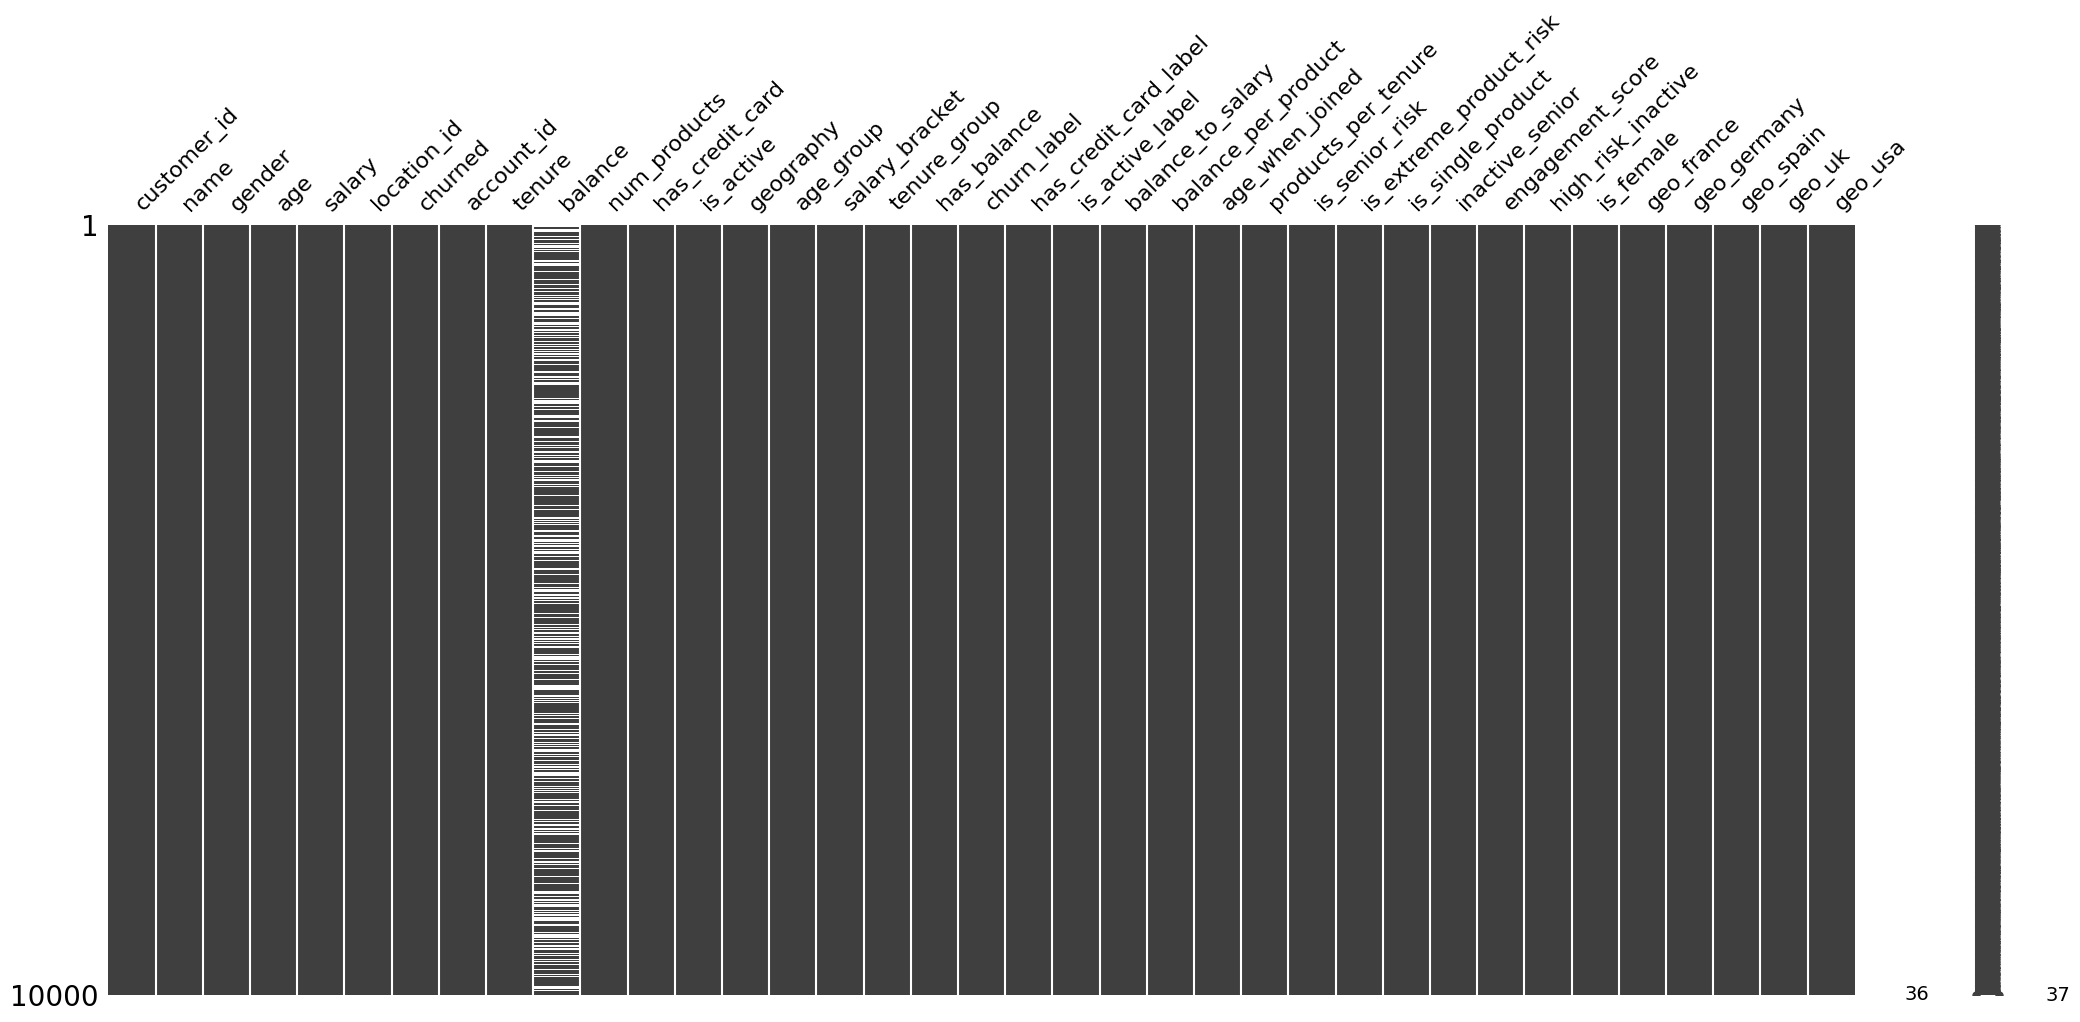

In [ ]:
# Missing-value matrix -- only Balance has nulls (36.17%)
msno.matrix(df)
plt.tight_layout()
plt.show()

In [ ]:
print(df['churned'].value_counts())
churn_rate = df['churned'].mean()
print('\nChurn rate: {:.2%}'.format(churn_rate))

churned
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.37%


In [ ]:
## Drop unnecessary features

drop_columns = ['has_balance',
        'products_per_tenure',
        'has_credit_card',
        'geo_france', 'geo_uk', 'geo_usa', 'geo_spain', 'geo_germany',
        'tenure', 'salary',
        'customer_id',
        'account_id', 'name', 'location_id',
        "age_when_joined","age",
        "churn_label",
        "has_credit_card_label",
        "is_active_label"]

In [ ]:
df = df.drop(columns=drop_columns)

In [ ]:
df.head()

,gender,churned,balance,num_products,is_active,geography,age_group,salary_bracket,tenure_group,balance_to_salary,balance_per_product,is_senior_risk,is_extreme_product_risk,is_single_product,inactive_senior,engagement_score,high_risk_inactive,is_female
0,female,1,NaN,1,1,france,36-45,high,new (0-2),0.000000,0.000000,0,0,1,0,0.750000,0,1
1,female,0,83807.86,1,1,usa,36-45,high,new (0-2),0.744670,83807.860000,0,0,1,0,0.416667,0,1
2,female,1,159660.80,3,0,uk,36-45,high,veteran (8-10),1.401362,53220.266667,0,1,0,0,0.583333,0,1
3,female,0,NaN,2,0,germany,36-45,medium,new (0-2),0.000000,0.000000,0,0,0,0,0.166667,1,1
4,female,0,125510.82,1,1,uk,36-45,medium,new (0-2),1.587035,125510.820000,0,0,1,0,0.750000,0,1


## Experiment 1A: Drop Missing Values

In [ ]:
import mlflow

In [ ]:
mlflow.set_tracking_uri('https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow')
mlflow.set_experiment('Experiment 1 - Keep Vs Drop Missing Values')

<Experiment: artifact_location='mlflow-artifacts:/ba00d5502a2e46c3899aa8836b0bafd4', creation_time=1788836276451, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1788836276451, lifecycle_stage='active', name='Experiment 1 - Keep Vs Drop Missing Values', tags={}, trace_location=None, workspace='default'>

In [ ]:
temp_df = df.copy().dropna()

In [ ]:
# split into X and y

X = temp_df.drop(columns="churned")
y = temp_df['churned']

X

,gender,balance,num_products,is_active,geography,age_group,salary_bracket,tenure_group,balance_to_salary,balance_per_product,is_senior_risk,is_extreme_product_risk,is_single_product,inactive_senior,engagement_score,high_risk_inactive,is_female
1,female,83807.86,1,1,usa,36-45,high,new (0-2),0.744670,83807.860000,0,0,1,0,0.416667,0,1
2,female,159660.80,3,0,uk,36-45,high,veteran (8-10),1.401362,53220.266667,0,1,0,0,0.583333,0,1
4,female,125510.82,1,1,uk,36-45,medium,new (0-2),1.587035,125510.820000,0,0,1,0,0.750000,0,1
5,male,113755.78,2,0,germany,36-45,high,veteran (8-10),0.759599,56877.890000,0,0,0,0,0.500000,0,0
7,female,115046.74,4,0,germany,26-35,high,mid (3-5),0.963961,28761.685000,0,1,0,0,0.666667,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,female,88381.21,1,0,uk,46-60,medium,mid (3-5),1.273767,88381.210000,1,0,1,1,0.416667,0,1
9993,male,155060.41,1,0,germany,26-35,low,senior (6-7),5.313833,155060.410000,0,0,1,0,0.416667,0,0
9996,male,57369.61,1,1,uk,26-35,high,veteran (8-10),0.564102,57369.610000,0,0,1,0,0.750000,0,0
9998,male,75075.31,2,0,usa,36-45,medium,mid (3-5),0.808222,37537.655000,0,0,0,0,0.500000,0,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print('Train size : {:,}  |  churn rate: {:.2%}'.format(X_train.shape[0], y_train.mean()))
print('Test  size : {:,}  |  churn rate: {:.2%}'.format(X_test.shape[0], y_test.mean()))

Train size : 5,106  |  churn rate: 24.09%
Test  size : 1,277  |  churn rate: 24.04%


In [ ]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (5106, 17)
The shape of test data is (1277, 17)


In [ ]:
# check for missing data in training data

X_train.isna().sum()

,0
gender,0
balance,0
num_products,0
is_active,0
geography,0
age_group,0
salary_bracket,0
tenure_group,0
balance_to_salary,0
balance_per_product,0


In [ ]:
X_train.columns

Index(['gender', 'balance', 'num_products', 'is_active', 'geography',
       'age_group', 'salary_bracket', 'tenure_group', 'balance_to_salary',
       'balance_per_product', 'is_senior_risk', 'is_extreme_product_risk',
       'is_single_product', 'inactive_senior', 'engagement_score',
       'high_risk_inactive', 'is_female'],
      dtype='object')

In [ ]:
numeric_cols     = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
binary_cols      = [c for c in numeric_cols if X[c].nunique() == 2]
scale_cols       = [c for c in numeric_cols if c not in binary_cols]

print('Numeric (scale)  :', scale_cols)
print('Binary pass-thru :', binary_cols)
print('Categorical OHE  :', categorical_cols)

Numeric (scale)  : ['balance', 'num_products', 'balance_to_salary', 'balance_per_product', 'engagement_score']
Binary pass-thru : ['is_active', 'is_senior_risk', 'is_extreme_product_risk', 'is_single_product', 'inactive_senior', 'high_risk_inactive', 'is_female']
Categorical OHE  : ['gender', 'geography', 'age_group', 'salary_bracket', 'tenure_group']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("scale", MinMaxScaler(), scale_cols),
        ("nominal_encode", OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_cols),
    ],
    remainder="passthrough",
    n_jobs=-1,
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")

ColumnTransformer(n_jobs=-1, remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['balance', 'num_products',
                                  'balance_to_salary', 'balance_per_product',
                                  'engagement_score']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['gender', 'geography', 'age_group',
                                  'salary_bracket', 'tenure_group'])],
                  verbose_feature_names_out=False)

In [ ]:
X_train_drop = preprocessor.fit_transform(X_train)
X_test_drop  = preprocessor.transform(X_test)

In [ ]:
X_train_drop

,balance,num_products,balance_to_salary,balance_per_product,engagement_score,gender_male,geography_france,geography_germany,geography_spain,geography_uk,...,tenure_group_new (0-2),tenure_group_senior (6-7),tenure_group_veteran (8-10),is_active,is_senior_risk,is_extreme_product_risk,is_single_product,inactive_senior,high_risk_inactive,is_female
350,0.420126,0.333333,0.000105,0.219501,0.818182,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1,0,0,0,0,0,0
6747,0.505706,0.000000,0.000096,0.536395,0.363636,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0,1,0,0,0
249,0.496296,0.000000,0.000094,0.526563,0.363636,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0,1,0,1,1,0,0
8198,0.525708,0.000000,0.000069,0.557295,0.363636,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0,1,0,0,1
8150,0.403993,0.333333,0.000121,0.211072,0.454545,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8867,0.650381,0.000000,0.000101,0.687571,0.727273,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1,0,0,1,0,0,1
2369,0.463208,0.000000,0.000068,0.491988,0.363636,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0,1,0,1,1,0,1
8102,0.664901,0.333333,0.000146,0.347388,0.454545,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1,1,0,0,0,0,1
352,0.670219,0.000000,0.000278,0.708300,0.363636,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0,0,0,1,0,0,1


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train_drop,y_train)

RandomForestClassifier()

In [ ]:
# get the predictions
y_pred_train = rf.predict(X_train_drop)
y_pred_test = rf.predict(X_test_drop)

In [ ]:
print(classification_report(y_train,y_pred_train))
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3876
           1       1.00      1.00      1.00      1230

    accuracy                           1.00      5106
   macro avg       1.00      1.00      1.00      5106
weighted avg       1.00      1.00      1.00      5106

              precision    recall  f1-score   support

           0       0.85      0.94      0.89       970
           1       0.72      0.45      0.56       307

    accuracy                           0.83      1277
   macro avg       0.78      0.70      0.72      1277
weighted avg       0.82      0.83      0.81      1277



In [ ]:
roc_auc_a = roc_auc_score(y_test, y_pred_test)
recall_a   = recall_score(y_test, y_pred_test)
accuracy_a = accuracy_score(y_test, y_pred_test)

In [ ]:
roc_auc_score(y_train, y_pred_train)
recall_score(y_train, y_pred_train)
accuracy_score(y_train, y_pred_train)

1.0

In [ ]:
from sklearn.metrics import confusion_matrix

print("Test size:", len(y_test))
print("Actual classes:")
print(y_test.value_counts())

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=["Stayed", "Churned"]
))

Test size: 1277
Actual classes:
churned
0    970
1    307
Name: count, dtype: int64

Confusion Matrix:
[[916  54]
 [168 139]]

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.94      0.89       970
     Churned       0.72      0.45      0.56       307

    accuracy                           0.83      1277
   macro avg       0.78      0.70      0.72      1277
weighted avg       0.82      0.83      0.81      1277



In [ ]:
print(roc_auc_a, recall_a, accuracy_a)

0.6985493132744551 0.4527687296416938 0.8261550509005482


#### Applying cross-validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
clf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [ ]:
scoring = {
    "roc_auc": "roc_auc",
    "recall": "recall",
    "accuracy": "accuracy",
}

In [ ]:
cv_results = cross_validate(
    clf_pipeline,
    X_train,          # raw X_train, NOT X_train_drop
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
)

In [ ]:
results_df = pd.DataFrame(cv_results)
print(results_df)


   fit_time  score_time  test_roc_auc  train_roc_auc  test_recall  \
0  1.350840    0.135989      0.756532            1.0     0.382114   
1  1.315791    0.134882      0.771602            1.0     0.394309   
2  1.337244    0.133367      0.783242            1.0     0.447154   
3  1.328681    0.130876      0.816218            1.0     0.495935   
4  0.862292    0.094873      0.756491            1.0     0.398374   

   train_recall  test_accuracy  train_accuracy  
0      0.998984       0.797456        0.999755  
1      1.000000       0.811949        1.000000  
2      1.000000       0.813908        1.000000  
3      1.000000       0.825661        1.000000  
4      1.000000       0.808031        1.000000  


In [ ]:
results_df["test_recall"].mean()

np.float64(0.4235772357723577)

In [ ]:
# log experiment

with mlflow.start_run(run_name="Drop Missing Values"):
    # mlflow log experiment type
    mlflow.log_param("experiment_type","Drop Missing Values")
    # log model params
    mlflow.log_params(rf.get_params())

    # log metrics
    mlflow.log_metric("training_accuracy",accuracy_score(y_train,y_pred_train))
    mlflow.log_metric("test_accuarcy",accuracy_score(y_test,y_pred_test))
    mlflow.log_metric("training_recall",recall_score(y_train,y_pred_train))
    mlflow.log_metric("test_recall",recall_score(y_test,y_pred_test))
    mlflow.log_metric("training_roc_auc",roc_auc_score(y_train,y_pred_train))
    mlflow.log_metric("test_roc_auc",roc_auc_score(y_test,y_pred_test))
    mlflow.log_metric("cross_val",results_df["test_recall"].mean())


🏃 View run Drop Missing Values at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/0/runs/c623a7f711dc4b06a3b63d9fa83e52fc
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/0


## Experiment 1B: Keep Missing Values

In [ ]:
keep_df = df.copy()

In [ ]:
keep_df.columns

Index(['gender', 'churned', 'balance', 'num_products', 'is_active',
       'geography', 'age_group', 'salary_bracket', 'tenure_group',
       'balance_to_salary', 'balance_per_product', 'is_senior_risk',
       'is_extreme_product_risk', 'is_single_product', 'inactive_senior',
       'engagement_score', 'high_risk_inactive', 'is_female'],
      dtype='object')

In [ ]:
### Split into train and test
X = keep_df.drop(columns="churned")
y = keep_df['churned']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (8000, 17)
The shape of test data is (2000, 17)


In [ ]:
# missing values in train data

X_train.isna().sum()

,0
gender,0
balance,2918
num_products,0
is_active,0
geography,0
age_group,0
salary_bracket,0
tenure_group,0
balance_to_salary,0
balance_per_product,0


#### Imputation

In [ ]:
# knn imputer

knn_imputer = KNNImputer(n_neighbors=10)

In [ ]:
preprocessing = Pipeline(steps = [
    ("prerocessor", preprocessor),
    ("imputer", knn_imputer)
])

In [ ]:
preprocessing

Pipeline(steps=[('prerocessor',
                 ColumnTransformer(n_jobs=-1, remainder='passthrough',
                                   transformers=[('scale', MinMaxScaler(),
                                                  ['balance', 'num_products',
                                                   'balance_to_salary',
                                                   'balance_per_product',
                                                   'engagement_score']),
                                                 ('nominal_encode',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'geography',
                                                   'age_group',
                                                   'salary_bracket',
                                                   'tenure_group'])],
                                   verbose_feature_names_out=False)),
                ('imputer', KNNImputer(n_neighbors=10))])

In [ ]:
model_pipe = Pipeline(steps=[
                                ("preprocessing",preprocessing),
                                ("model",rf)
                            ])

model_pipe

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('prerocessor',
                                  ColumnTransformer(n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('scale',
                                                                   MinMaxScaler(),
                                                                   ['balance',
                                                                    'num_products',
                                                                    'balance_to_salary',
                                                                    'balance_per_product',
                                                                    'engagement_score']),
                                                                  ('nominal_encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False),
                                                                   ['gender',
                                                                    'geography',
                                                                    'age_group',
                                                                    'salary_bracket',
                                                                    'tenure_group'])],
                                                    verbose_feature_names_out=False)),
                                 ('imputer', KNNImputer(n_neighbors=10))])),
                ('model', RandomForestClassifier())])

In [ ]:
model_pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('prerocessor',
                                  ColumnTransformer(n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('scale',
                                                                   MinMaxScaler(),
                                                                   ['balance',
                                                                    'num_products',
                                                                    'balance_to_salary',
                                                                    'balance_per_product',
                                                                    'engagement_score']),
                                                                  ('nominal_encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False),
                                                                   ['gender',
                                                                    'geography',
                                                                    'age_group',
                                                                    'salary_bracket',
                                                                    'tenure_group'])],
                                                    verbose_feature_names_out=False)),
                                 ('imputer', KNNImputer(n_neighbors=10))])),
                ('model', RandomForestClassifier())])

In [ ]:
# get the predictions
y_pred_train = model_pipe.predict(X_train)
y_pred_test = model_pipe.predict(X_test)

In [ ]:
roc_auc_b = roc_auc_score(y_test, y_pred_test)
recall_b   = recall_score(y_test, y_pred_test)
accuracy_b = accuracy_score(y_test, y_pred_test)

In [ ]:
print(f"The training accuracy is {accuracy_score(y_train,y_pred_train)}")
print(f"The test accuracy is {accuracy_score(y_test,y_pred_test)}")

The training accuracy is 0.993
The test accuracy is 0.8495


In [ ]:
print(f"The training recall is {recall_score(y_train,y_pred_train)}")
print(f"The test recall is {recall_score(y_test,y_pred_test)}")

The training recall is 0.9732360097323601
The test recall is 0.43256997455470736


In [ ]:
print(f"The training roc_auc is {roc_auc_score(y_train,y_pred_train)}")
print(f"The test roc_auc is {roc_auc_score(y_test,y_pred_test)}")

The training roc_auc is 0.9856740149354062
The test roc_auc is 0.6920161633818963


In [ ]:
cv_results = cross_validate(
    model_pipe,
    X_train,          # raw X_train, NOT X_train_drop
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
)

In [ ]:
cv_results

{'fit_time': array([8.20789289, 8.17853355, 5.93465257, 5.69698405, 5.63971639]),
 'score_time': array([2.07372165, 1.73154593, 1.30384088, 1.23759651, 1.71145201]),
 'test_roc_auc': array([0.83038762, 0.81472598, 0.81557613, 0.82102621, 0.82132514]),
 'train_roc_auc': array([0.99974643, 0.99967331, 0.99980476, 0.99978846, 0.99984492]),
 'test_recall': array([0.42682927, 0.44984802, 0.47112462, 0.41641337, 0.46200608]),
 'train_recall': array([0.97568389, 0.97110266, 0.97870722, 0.97794677, 0.97870722]),
 'test_accuracy': array([0.84    , 0.84125 , 0.84625 , 0.839375, 0.8475  ]),
 'train_accuracy': array([0.99421875, 0.993125  , 0.9946875 , 0.994375  , 0.994375  ])}

In [ ]:
# log experiment

with mlflow.start_run(run_name="Impute Missing Values"):
    # mlflow log experiment type
    mlflow.log_param("experiment_type","Impute Missing Values")
    # log model params
    mlflow.log_params(rf.get_params())

    # log metrics
    mlflow.log_metric("training_accuracy",accuracy_score(y_train,y_pred_train))
    mlflow.log_metric("test_accuarcy",accuracy_score(y_test,y_pred_test))
    mlflow.log_metric("training_recall",recall_score(y_train,y_pred_train))
    mlflow.log_metric("test_recall",recall_score(y_test,y_pred_test))
    mlflow.log_metric("training_roc_auc",roc_auc_score(y_train,y_pred_train))
    mlflow.log_metric("test_roc_auc",roc_auc_score(y_test,y_pred_test))
    mlflow.log_metric("cross_val",results_df["test_recall"].mean())


🏃 View run Impute Missing Values at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/0/runs/70569a97a6004437966da62ac3493601
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/0
